# 第十章 — 多维指标评测体系与迭代复盘

**10.1** 核心评估矩阵建设（算法指标 + 工程指标）、**10.2** 三代模型横向对比与 A/B 压测
（V1 专家拼接 / V2 深度融合 / V3 VLM，分标签表现 + 算力性价比）、**10.3** 结课复盘
（VLM 幻觉问题实测 + RAG 外挂法规知识库方向）。

规矩不变：**问题/原理/结论在 markdown，代码在 cell**，输出为 L4 24GB 上的真实运行结果。
测不到的部分（如无本地权重的 I3D）建**成本模型并明确标注"估算"**，不与实测混为一谈。

## 10.1 核心评估矩阵建设

### 算法指标：为什么审核场景里 Recall 优先

审核的代价函数是**极度不对称**的：漏放（FN）一条暴力内容可能导致下架、罚款、舆情事件；
误杀（FP）一条正常内容只是多一次人工复审。所以：

| 指标 | 定义 | 在审核场景的地位 |
|---|---|---|
| **Recall** | TP/(TP+FN) | **第一优先**。"宁可误杀不可漏放"翻译成指标就是 recall 下限约束 |
| Precision | TP/(TP+FP) | 约束项——它决定人工复审队列的长度（成本），不是目标 |
| F1 | 调和平均 | 汇报用的单值摘要，但**它把 P 和 R 等权，与业务代价不符** |
| **F-β (β=2)** | (1+β²)PR/(β²P+R) | **更贴合审核**：β=2 时召回权重是精确率的 4 倍 |
| ROC-AUC | 排序质量，阈值无关 | 选型看它——它衡量"模型能不能排对"，与运营阈值解耦 |
| PR-AUC (AP) | 正类稀疏时比 ROC 更敏感 | 真实流量里暴力占比远低于我们数据集的 46%，生产应看 AP |
| **Recall@FPR=1%** | 固定误杀预算下的召回 | **最接近业务合同的单一数字**：给定人工复审预算，能抓住多少 |

本章统一报告：P / R / F1 / **F2** / ROC-AUC / AP / **Recall@FPR=1%**。

### 工程指标：端到端延迟的正确定义

**端到端 = 从视频输入到 JSON 吐出**，必须包含：视频解码 → 特征提取/抽帧 → 模型前向 →
后处理成 JSON。只报"模型前向耗时"是耍流氓——我们自己在第九章就踩过这个坑
（把 CPU 预处理算进了 GPU 利用率的采样窗口，导致利用率数字失真）。本章的计时**分段进行**：
每段单独计时、各自热身，CPU 段与 GPU 段分开归因。

| 指标 | 口径 |
|---|---|
| **Latency p50 / p95 / p99** | 单条端到端墙钟时间。审核是异步任务，p99 比 p50 更重要（队列积压看尾部） |
| **QPS** | 饱和吞吐 = 1 / (批处理下的摊薄单条耗时)。**必须注明 batch 与并发**，否则无意义 |
| **GPU Memory** | 峰值显存（`max_memory_allocated`）——决定单卡能并存几个模型、能否与其他服务共卡 |
| **成本性价比** | 我们用 **GPU-秒 / 千条** 和 **F2 每 GPU-秒**，把质量和算力放进同一个分母 |

In [1]:
import gc, glob, json, os, subprocess, tempfile, time
import numpy as np
import torch

DATA = os.path.expanduser("~/documents/SentinelAI/data/xd-violence")
FRAMES = f"{DATA}/frames16"
ADAPTER = f"{DATA}/qwen_qlora_adapter"
I3D = f"{DATA}/data/i3d_rgb"
DIRS = ["1-1004", "1005-2004", "2005-2804", "2805-3319", "3320-3954", "test_videos"]
VLM_MODEL = "Qwen/Qwen2.5-VL-7B-Instruct"
N_IMG, V_TOK, A_TOK = 8, 32, 16
DEV = "cuda"

from sklearn.metrics import (average_precision_score, f1_score, fbeta_score,
                             precision_score, recall_score, roc_auc_score, roc_curve)

def algo_metrics(y, p, thr=0.5):
    """审核口径的算法指标全家桶。"""
    pred = (p >= thr).astype(int)
    fpr, tpr, _ = roc_curve(y, p)
    r_at_1pct = float(tpr[np.searchsorted(fpr, 0.01, side="right") - 1])  # Recall @ FPR=1%
    return {"P": precision_score(y, pred, zero_division=0), "R": recall_score(y, pred),
            "F1": f1_score(y, pred), "F2": fbeta_score(y, pred, beta=2),
            "AUC": roc_auc_score(y, p), "AP": average_precision_score(y, p),
            "R@FPR1%": r_at_1pct}

class Stage:
    """分段计时 + 峰值显存：热身 warmup 次，再计时 n 次取分位数。"""
    def __init__(self, name): self.name = name
    def run(self, fn, n=20, warmup=3):
        for _ in range(warmup): fn()
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
        ts = []
        for _ in range(n):
            t0 = time.perf_counter(); fn(); torch.cuda.synchronize()
            ts.append(time.perf_counter() - t0)
        ts = np.array(ts) * 1e3
        return {"stage": self.name, "p50_ms": float(np.percentile(ts, 50)),
                "p95_ms": float(np.percentile(ts, 95)),
                "mem_GB": torch.cuda.max_memory_allocated() / 1e9}

def free():
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

def smi_mem_GB():
    """全卡已用显存。vLLM v1 把引擎跑在独立进程，父进程的 torch.cuda.memory_allocated()
    看不到它 —— 必须用 nvidia-smi 才能测到 VLM 的真实占用。"""
    out = subprocess.run(["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
                         capture_output=True, text=True).stdout.strip().splitlines()[0]
    return float(out) / 1024

print(f"GPU: {torch.cuda.get_device_name(0)}  "
      f"总显存 {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

GPU: NVIDIA L4  总显存 23.7 GB


## 10.2 三代模型横向对比

### 三代定义与公平性协议

| 代 | 架构 | 可训练参数 |
|---|---|---|
| **V1 专家拼接** | I3D + AST + 文本嵌入 **特征拼接 → 逻辑回归**（③ feature-concat） | 3585 |
| **V2 深度融合** | **① early fusion joint transformer**：三模态 token 序列进同一个 transformer 自注意力 | ~0.4M |
| **V3 VLM** | Qwen2.5-VL-7B + QLoRA adapter（8 帧直接进 VLM） | 40M (0.57%) |

**公平性协议（这是 A/B test 成立的前提）**：

1. **同一切分**：复现 QLoRA 微调时用的 `GroupShuffleSplit(test_size=0.2, random_state=0)`
   **电影分组**切分——V1/V2 在同一批训练电影上训练，三代在**同一批测试片段**上评测；
2. **零泄漏**：同一部电影的片段绝不跨越训练/测试（这个数据集上镜头风格、配乐、演员高度相似，
   随机切分会严重高估）；
3. **同一输入源**：测试集取 `frames16`（V3 需要帧）与三模态特征的**交集**，三代看的是同一批片段。

In [2]:
def b(n): return n.replace(".npy", "").replace(".mp4", "")
def is_violent(k): return 0 if "_label_A" in k else 1
def label_code(k): return k.split("_label_")[1].split("-")[0] if "_label_" in k else "?"
def resample(x, n):
    if len(x) == 0: return np.zeros((n, x.shape[1]), np.float32)
    return x[np.linspace(0, len(x) - 1, n).round().astype(int)].astype(np.float32)

def load_npz_dir(d, field="embedding"):
    out = {}
    for f in glob.glob(f"{d}/*.npz"):
        z = np.load(f, allow_pickle=True); out[str(z["key"])] = z[field].astype(np.float32)
    return out

vis_seq = {}
for d in DIRS:
    for f in glob.glob(f"{I3D}/{d}/*.npy"):
        a = np.load(f); a = a.mean(1) if a.ndim == 3 else a
        vis_seq[b(os.path.basename(f))] = a.astype(np.float32)
aud_pool = load_npz_dir(f"{DATA}/audio_full")
aud_seq  = load_npz_dir(f"{DATA}/audio_seq", "sequence")
txt_pool = load_npz_dir(f"{DATA}/text_features")

# 复现 QLoRA 的电影分组切分（同一 random_state / 同一文件列表顺序）
from sklearn.model_selection import GroupShuffleSplit
files = sorted(glob.glob(f"{FRAMES}/*.npz"))
fkeys = [os.path.splitext(os.path.basename(f))[0] for f in files]
fy = np.array([is_violent(k) for k in fkeys])
fg = np.array([k.split("__")[0] for k in fkeys])
tr_idx, te_idx = next(GroupShuffleSplit(1, test_size=0.2, random_state=0).split(files, fy, fg))
train_movies = set(fg[tr_idx]); test_movies = set(fg[te_idx])

# 三模态齐全 ∩ 有帧 —— 三代共同的评测底座
allk = [k for k in fkeys if k in vis_seq and k in aud_pool and k in aud_seq and k in txt_pool]
K_tr = [k for k in allk if k.split("__")[0] in train_movies]
K_te = [k for k in allk if k.split("__")[0] in test_movies]
y_tr = np.array([is_violent(k) for k in K_tr]); y_te = np.array([is_violent(k) for k in K_te])
print(f"共同底座: 训练 {len(K_tr)} / 测试 {len(K_te)} 片段, "
      f"{len(train_movies)} / {len(test_movies)} 部电影 (不相交)")
print(f"测试集暴力占比 {y_te.mean():.0%}; 各标签: "
      f"{dict(zip(*np.unique([label_code(k) for k in K_te], return_counts=True)))}")

def stack(keys):
    Vp = np.stack([vis_seq[k].mean(0) for k in keys]); Ap = np.stack([aud_pool[k] for k in keys])
    Tp = np.stack([txt_pool[k] for k in keys])
    Vs = np.stack([resample(vis_seq[k], V_TOK) for k in keys])
    As = np.stack([resample(aud_seq[k], A_TOK) for k in keys])
    return Vp, Ap, Tp, Vs, As
Vp_tr, Ap_tr, Tp_tr, Vs_tr, As_tr = stack(K_tr)
Vp_te, Ap_te, Tp_te, Vs_te, As_te = stack(K_te)

共同底座: 训练 894 / 测试 295 片段, 1496 / 375 部电影 (不相交)
测试集暴力占比 37%; 各标签: {np.str_('A'): np.int64(185), np.str_('B1'): np.int64(49), np.str_('B2'): np.int64(39), np.str_('B4'): np.int64(2), np.str_('B5'): np.int64(8), np.str_('B6'): np.int64(7), np.str_('G'): np.int64(5)}


In [3]:
# ── V1 专家拼接: 特征 concat + LR ──
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_tr = np.concatenate([Vp_tr, Ap_tr, Tp_tr], 1); X_te = np.concatenate([Vp_te, Ap_te, Tp_te], 1)
t0 = time.time()
v1 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)).fit(X_tr, y_tr)
p_v1 = v1.predict_proba(X_te)[:, 1]
print(f"V1 训练 {time.time()-t0:.1f}s")

# ── V2 深度融合: early fusion joint transformer ──
from torch import nn
from sentinelai.early_fusion import JointFusionTransformer

torch.manual_seed(0)
v2 = JointFusionTransformer({"visual": 2048, "audio": 768, "text": 768},
                            d_model=128, n_layers=2, n_categories=1).to(DEV)
opt = torch.optim.AdamW(v2.parameters(), 1e-3); lf = nn.BCEWithLogitsLoss()
T = {"visual": torch.tensor(Vs_tr, device=DEV), "audio": torch.tensor(As_tr, device=DEV),
     "text": torch.tensor(Tp_tr[:, None, :], device=DEV)}
E = {"visual": torch.tensor(Vs_te, device=DEV), "audio": torch.tensor(As_te, device=DEV),
     "text": torch.tensor(Tp_te[:, None, :], device=DEV)}
yt = torch.tensor(y_tr, dtype=torch.float32, device=DEV)[:, None]
t0 = time.time()
for _ in range(200):
    v2.train(); opt.zero_grad(); o = v2(T); lo = o[0] if isinstance(o, tuple) else o
    lf(lo, yt).backward(); opt.step()
v2.eval()
with torch.no_grad():
    o = v2(E); lo = o[0] if isinstance(o, tuple) else o
    p_v2 = torch.sigmoid(lo).squeeze(1).cpu().numpy()
print(f"V2 训练 {time.time()-t0:.1f}s  ({sum(p.numel() for p in v2.parameters())/1e6:.2f}M 参数)")
# 训练张量占显存近 1GB（Vs_tr 是 N×32×2048），测完立刻释放，给后面的 vLLM 腾 KV 池
E1 = {k: v[:1].clone() for k, v in E.items()}          # .clone() 否则切片视图仍持有整块存储
del T, E, yt, opt
gc.collect(); torch.cuda.empty_cache()

V1 训练 0.8s


V2 训练 9.9s  (0.86M 参数)


### 工程指标 A：V1/V2 的端到端延迟分解

先测**特征提取链路**（V1/V2 真正的耗时大头），再测融合头。顺序很重要：编码器先测完释放，
之后才加载 vLLM（它会预占 80% 显存）。
视觉分支用仓库里的 `VisualExpert`（ResNet-50）实测；**I3D 无本地权重，另按 FLOPs 估算并标注**。

In [4]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoProcessor
eng_rows = []

# (a) 视频解码 + 抽帧：拉一条真实 mp4 实测
decode_ms = None
try:
    from huggingface_hub import hf_hub_download
    vmap = json.load(open(f"{DATA}/add_normals/vmap.json"))
    vk = next(k for k in K_te if k in vmap)
    tmpd = tempfile.mkdtemp()
    vp = hf_hub_download("jherng/xd-violence", vmap[vk], repo_type="dataset", local_dir=tmpd)
    def _decode():
        subprocess.run(["ffmpeg", "-nostdin", "-loglevel", "error", "-i", vp,
                        "-vf", "fps=16/60,scale=224:224", "-frames:v", "16",
                        f"{tmpd}/f_%02d.jpg", "-y"], check=False)
    t0 = time.perf_counter(); [_decode() for _ in range(3)]; decode_ms = (time.perf_counter()-t0)/3*1e3
    def _wav():
        subprocess.run(["ffmpeg", "-nostdin", "-loglevel", "error", "-i", vp,
                        "-ac", "1", "-ar", "16000", f"{tmpd}/a.wav", "-y"], check=False)
    _wav(); wav_path = f"{tmpd}/a.wav"
    print(f"视频解码+抽16帧: {decode_ms:.0f} ms (实测, 1 条真实 mp4)")
    eng_rows.append({"stage": "视频解码+抽帧", "p50_ms": decode_ms, "p95_ms": decode_ms, "mem_GB": 0.0})
except Exception as e:
    wav_path = None; print("视频下载失败, 解码段跳过:", str(e)[:100])

# (b) 视觉: ResNet-50 (V1 的 VisualExpert 实现) —— I3D 见下方估算
from sentinelai.visual_expert import VisualExpert
from PIL import Image
vex = VisualExpert(backbone="resnet50", device=DEV)
imgs16 = [Image.fromarray(np.load(f"{FRAMES}/{K_te[0]}.npz", allow_pickle=True)["frames"][i])
          for i in range(16)]
eng_rows.append(Stage("视觉 ResNet-50 (16帧)").run(lambda: vex.extract_features(imgs16), n=10))
del vex; free()

# (c) 音频 AST
from sentinelai.audio_expert import AudioExpert
aex = AudioExpert(device=DEV)
if wav_path:
    eng_rows.append(Stage("音频 AST").run(lambda: aex.extract_features(wav_path), n=5, warmup=1))
del aex; free()

# (d) ASR: faster-whisper —— V1/V2 文本分支的入口
if wav_path:
    from faster_whisper import WhisperModel
    asr = WhisperModel("base", device="cuda", compute_type="float16")
    def _asr():
        segs, _ = asr.transcribe(wav_path, beam_size=1)
        return " ".join(s.text for s in segs)
    txt_demo = _asr()
    eng_rows.append(Stage("ASR faster-whisper-base").run(_asr, n=3, warmup=1))
    del asr; free()
else:
    txt_demo = "placeholder"

# (e) 文本嵌入 XLM-R
TEXT_MODEL = "unitary/multilingual-toxic-xlm-roberta"
ttok = AutoTokenizer.from_pretrained(TEXT_MODEL)
tmdl = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL, output_hidden_states=True).to(DEV).eval()
def _txt():
    enc = ttok(txt_demo[:2000], return_tensors="pt", truncation=True, max_length=512).to(DEV)
    with torch.no_grad(): tmdl(**enc)
eng_rows.append(Stage("文本嵌入 XLM-R").run(_txt, n=10))
del tmdl; free()

# (f) 融合头
import onnxruntime as ort
if os.path.exists(f"{DATA}/fusion_concat_lr.onnx"):
    sess = ort.InferenceSession(f"{DATA}/fusion_concat_lr.onnx", providers=["CPUExecutionProvider"])
    x1 = X_te[:1].astype(np.float32)
    t0 = time.perf_counter(); [sess.run(None, {sess.get_inputs()[0].name: x1}) for _ in range(200)]
    eng_rows.append({"stage": "V1 融合头 LR (CPU)", "p50_ms": (time.perf_counter()-t0)/200*1e3,
                     "p95_ms": float("nan"), "mem_GB": 0.0})
eng_rows.append(Stage("V2 融合头 transformer").run(lambda: v2(E1), n=50))

import pandas as pd
print(pd.DataFrame(eng_rows).round(2).to_string(index=False))

/home/miaojiang/vllm-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


视频解码+抽16帧: 550 ms (实测, 1 条真实 mp4)


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

Loading weights:  66%|██████▌   | 133/203 [00:00<00:00, 1326.33it/s]

Loading weights: 100%|██████████| 203/203 [00:00<00:00, 1339.65it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12427.29it/s]

                  stage  p50_ms  p95_ms  mem_GB
                视频解码+抽帧  549.82  549.82    0.00
     视觉 ResNet-50 (16帧)   41.96   42.24    0.30
                 音频 AST 1041.46 1048.00    2.44
ASR faster-whisper-base 1822.12 1823.80    0.02
             文本嵌入 XLM-R   14.53   15.15    1.18
        V1 融合头 LR (CPU)    0.09     NaN    0.00
     V2 融合头 transformer    2.36    2.45    0.03


### 工程指标 B：V3 的端到端延迟与显存

加载 vLLM（PagedAttention + continuous batching），测三件事：**冷启动/显存**、
**batch=1 端到端延迟**（含帧加载预处理，这才是真端到端）、**饱和吞吐**。

In [5]:
del v2, E1; free()
free_B, total_B = torch.cuda.mem_get_info()
print(f"vLLM 加载前: 空闲 {free_B/1e9:.1f} / {total_B/1e9:.1f} GB "
      f"(本进程 torch 占用 {torch.cuda.memory_allocated()/1e9:.2f} GB)")
from vllm import LLM, SamplingParams
from vllm.lora.request import LoRARequest

t0 = time.time()
llm = LLM(model=VLM_MODEL, dtype="bfloat16", gpu_memory_utilization=0.90,
          max_model_len=4096, limit_mm_per_prompt={"image": N_IMG}, enforce_eager=True,
          enable_lora=True, max_lora_rank=16)
load_s = time.time() - t0
lora = LoRARequest("violence", 1, ADAPTER)
proc = AutoProcessor.from_pretrained(VLM_MODEL)
PROMPT = ("You are given 8 frames evenly sampled from one video. Does the video depict "
          "physical violence (fighting, assault, weapons used against people, blood or injury)? "
          "Answer with exactly one word: yes or no.")
SPz = SamplingParams(temperature=0, max_tokens=1, logprobs=20)
print(f"vLLM 引擎加载 {load_s:.0f}s; 整卡已用显存 {smi_mem_GB():.1f} GB (nvidia-smi, 含引擎子进程)")
print("  引擎自报分解见上方日志: 权重 ~15.7 GiB + 峰值激活 ~2.0 GiB + KV cache ~1.6 GiB")

def load_frames(key):
    arr = np.load(f"{FRAMES}/{key}.npz", allow_pickle=True)["frames"]
    return [Image.fromarray(arr[i]) for i in range(0, len(arr), len(arr)//N_IMG)][:N_IMG]
def make_req(key):
    msgs = [{"role": "user", "content": [*[{"type": "image"} for _ in range(N_IMG)],
                                         {"type": "text", "text": PROMPT}]}]
    return {"prompt": proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True),
            "multi_modal_data": {"image": load_frames(key)}}
def p_yes(out):
    lp = out.outputs[0].logprobs[0]; py, pn = [], []
    for tid, l in lp.items():
        t = proc.tokenizer.decode([tid]).strip().lower()
        (py if t == "yes" else pn if t == "no" else []).append(l.logprob)
    ey, en = sum(np.exp(py)) if py else 0.0, sum(np.exp(pn)) if pn else 0.0
    return ey / (ey + en) if ey + en > 0 else 0.5

# 端到端 batch=1：预处理(CPU) 与 推理(GPU) 分开归因 —— 修正第九章的计时缺陷
pre_ms, inf_ms = [], []
for k in K_te[:30]:
    t0 = time.perf_counter(); req = make_req(k); t1 = time.perf_counter()
    llm.generate([req], SPz, lora_request=lora, use_tqdm=False); t2 = time.perf_counter()
    pre_ms.append((t1-t0)*1e3); inf_ms.append((t2-t1)*1e3)
pre_ms, inf_ms = np.array(pre_ms[5:]), np.array(inf_ms[5:])
e2e = pre_ms + inf_ms
print(f"V3 batch=1 端到端: p50 {np.percentile(e2e,50):.0f} ms  p95 {np.percentile(e2e,95):.0f} ms")
print(f"  其中 CPU 预处理(帧加载+模板) p50 {np.percentile(pre_ms,50):.0f} ms, "
      f"GPU 推理 p50 {np.percentile(inf_ms,50):.0f} ms")

vLLM 加载前: 空闲 23.4 / 23.7 GB (本进程 torch 占用 0.02 GB)


INFO 09-14 23:12:25 [api_utils.py:286] non-default args: {'dtype': 'bfloat16', 'max_model_len': 4096, 'gpu_memory_utilization': 0.9, 'disable_log_stats': True, 'enforce_eager': True, 'limit_mm_per_prompt': {'image': 8}, 'enable_lora': True, 'model': 'Qwen/Qwen2.5-VL-7B-Instruct'}


INFO 09-14 23:12:25 [model.py:684] Resolved architecture: Qwen2_5_VLForConditionalGeneration


INFO 09-14 23:12:25 [model.py:2021] Using max model len 4096


INFO 09-14 23:12:27 [scheduler.py:277] Chunked prefill is enabled with max_num_batched_tokens=8192.


...

INFO 09-14 23:13:42 [base.py:244] Multi-modal warmup completed in 15.984s


INFO 09-14 23:13:42 [base.py:244] Readonly multi-modal warmup completed in 0.544s


vLLM 引擎加载 77s; 整卡已用显存 18.7 GB (nvidia-smi, 含引擎子进程)
  引擎自报分解见上方日志: 权重 ~15.7 GiB + 峰值激活 ~2.0 GiB + KV cache ~1.6 GiB
WARNING 09-14 23:13:45 [input_processor.py:196] vLLM has deprecated support for supporting different tokenizers for different LoRAs. By default, vLLM uses base model's tokenizer. If you are using a LoRA with its own tokenizer, consider specifying `--tokenizer [lora_path]` to use the LoRA tokenizer.


(EngineCore pid=4024) WARNING 09-14 23:13:45 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _lora_shrink_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=4024) WARNING 09-14 23:13:45 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _lora_expand_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.
(EngineCore pid=4024) WARNING 09-14 23:13:45 [jit_monitor.py:141] Triton kernel JIT compilation during inference: _topk_log_softmax_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


V3 batch=1 端到端: p50 256 ms  p95 264 ms
  其中 CPU 预处理(帧加载+模板) p50 21 ms, GPU 推理 p50 236 ms


In [6]:
# 全测试集打分（adapter on = V3；adapter off = 零样本基线），顺带测饱和吞吐
reqs = [make_req(k) for k in K_te]
t0 = time.time(); outs_on = llm.generate(reqs, SPz, lora_request=lora, use_tqdm=False)
t_on = time.time() - t0
p_v3 = np.array([p_yes(o) for o in outs_on])
outs_off = llm.generate(reqs, SPz, use_tqdm=False)
p_zs = np.array([p_yes(o) for o in outs_off])
qps_v3 = len(K_te) / t_on
print(f"V3 全量打分 {len(K_te)} 条用时 {t_on:.1f}s → 饱和吞吐 {qps_v3:.1f} QPS "
      f"({t_on/len(K_te)*1e3:.0f} ms/clip 摊薄)")

V3 全量打分 295 条用时 55.5s → 饱和吞吐 5.3 QPS (188 ms/clip 摊薄)


                              P      R     F1     F2    AUC     AP  R@FPR1%
V1 专家拼接 (concat+LR)       0.962  0.909  0.935  0.919  0.983  0.978    0.782
V2 深度融合 (early transf.)   0.972  0.945  0.959  0.951  0.991  0.988    0.918
V3 VLM (QLoRA)            0.942  0.736  0.827  0.770  0.963  0.950    0.645
  └ V3 零样本 (adapter off)  1.000  0.227  0.370  0.269  0.926  0.917    0.518


/tmp/ipykernel_3754/2848898121.py:16: UserWarning: Glyph 19987 (\N{CJK UNIFIED IDEOGRAPH-4E13}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/2848898121.py:16: UserWarning: Glyph 23478 (\N{CJK UNIFIED IDEOGRAPH-5BB6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/2848898121.py:16: UserWarning: Glyph 25340 (\N{CJK UNIFIED IDEOGRAPH-62FC}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/2848898121.py:16: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/2848898121.py:16: UserWarning: Glyph 28145 (\N{CJK UNIFIED IDEOGRAPH-6DF1}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/2848898121.py:16: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/28

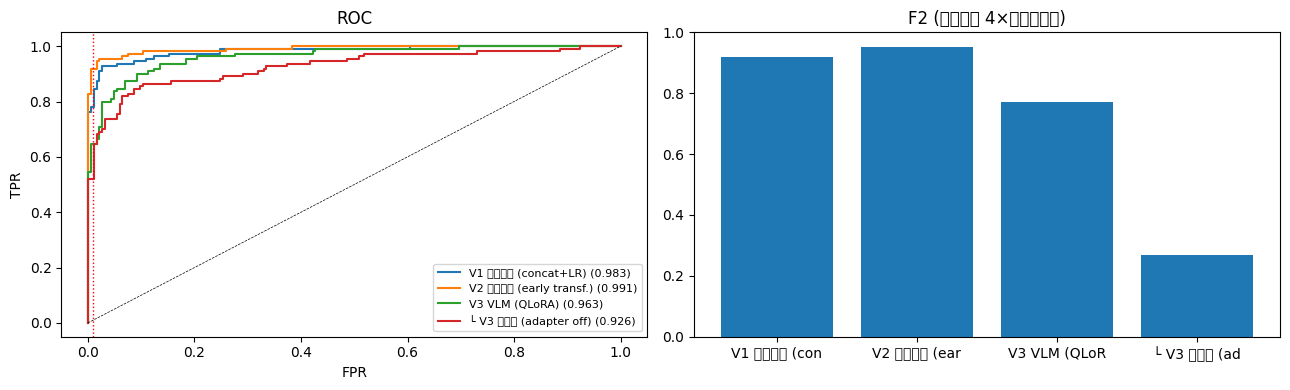

In [7]:
# ── 三代算法指标总表 ──
import matplotlib.pyplot as plt
rows = {"V1 专家拼接 (concat+LR)": p_v1, "V2 深度融合 (early transf.)": p_v2,
        "V3 VLM (QLoRA)": p_v3, "  └ V3 零样本 (adapter off)": p_zs}
tbl = pd.DataFrame({n: algo_metrics(y_te, p) for n, p in rows.items()}).T
print(tbl.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for n, p in rows.items():
    fpr, tpr, _ = roc_curve(y_te, p)
    ax[0].plot(fpr, tpr, label=f"{n.strip()} ({roc_auc_score(y_te,p):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=.5); ax[0].set(title="ROC", xlabel="FPR", ylabel="TPR")
ax[0].axvline(0.01, color="r", ls=":", lw=1); ax[0].legend(fontsize=8)
ax[1].bar(range(len(tbl)), tbl["F2"], tick_label=[n.strip()[:12] for n in tbl.index])
ax[1].set(title="F2 (召回权重 4×，审核口径)", ylim=(0, 1))
plt.tight_layout(); plt.show()

### 分标签表现差异

二分类模型在**不同违规类型**上的召回差异，是这套系统最该向业务方汇报的东西——
它直接决定"哪类违规会漏"。正常类（A）报**特异度**（1−FPR）。

各标签：正常类为特异度(1-FPR)，其余为该类召回
   标签   n  V1 专家拼接 (con  V2 深度融合 (ear  V3 VLM (QLoR  └ V3 零样本 (ad
 A 正常 185         0.978         0.984         0.973         1.000
B1 斗殴  49         0.878         0.939         0.816         0.245
B2 枪击  39         0.949         0.974         0.718         0.256
B5 虐待   8         0.750         0.875         0.625         0.125
B6 车祸   7         1.000         0.857         0.571         0.000
 G 爆炸   5         1.000         1.000         0.800         0.400


/tmp/ipykernel_3754/3602001981.py:25: UserWarning: Glyph 26007 (\N{CJK UNIFIED IDEOGRAPH-6597}) missing from font(s) DejaVu Sans.
  ax.legend(fontsize=8); plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/3602001981.py:25: UserWarning: Glyph 27572 (\N{CJK UNIFIED IDEOGRAPH-6BB4}) missing from font(s) DejaVu Sans.
  ax.legend(fontsize=8); plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/3602001981.py:25: UserWarning: Glyph 26538 (\N{CJK UNIFIED IDEOGRAPH-67AA}) missing from font(s) DejaVu Sans.
  ax.legend(fontsize=8); plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/3602001981.py:25: UserWarning: Glyph 20987 (\N{CJK UNIFIED IDEOGRAPH-51FB}) missing from font(s) DejaVu Sans.
  ax.legend(fontsize=8); plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/3602001981.py:25: UserWarning: Glyph 34384 (\N{CJK UNIFIED IDEOGRAPH-8650}) missing from font(s) DejaVu Sans.
  ax.legend(fontsize=8); plt.tight_layout(); plt.show()
/tmp/ipykernel_3754/3602001981.py:25: UserWarning: Glyph 24453 (\N{CJK

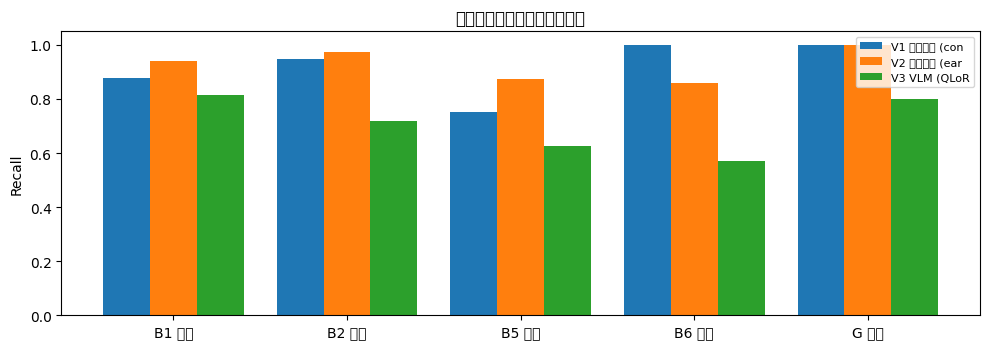

In [8]:
codes = np.array([label_code(k) for k in K_te])
CODE_NAME = {"A": "正常", "B1": "斗殴", "B2": "枪击", "B4": "骚乱",
             "B5": "虐待", "B6": "车祸", "G": "爆炸"}
per = []
for c in sorted(set(codes)):
    m = codes == c
    if m.sum() < 5: continue
    row = {"标签": f"{c} {CODE_NAME.get(c, '?')}", "n": int(m.sum())}
    for n, p in rows.items():
        pred = (p[m] >= 0.5).astype(int)
        row[n.strip()[:12]] = (1 - pred.mean()) if c == "A" else pred.mean()  # A=特异度, 其余=召回
    per.append(row)
per = pd.DataFrame(per)
print("各标签：正常类为特异度(1-FPR)，其余为该类召回")
print(per.round(3).to_string(index=False))

sub = per[per["标签"].str.startswith(("B", "G"))]
model_cols = [c for c in per.columns if c not in ("标签", "n")][:3]      # V1/V2/V3
x = np.arange(len(sub)); w = 0.27
fig, ax = plt.subplots(figsize=(10, 3.6))
for i, col in enumerate(model_cols):
    ax.bar(x + (i-1)*w, sub[col], w, label=col)
ax.set_xticks(x); ax.set_xticklabels(sub["标签"]); ax.set(ylabel="Recall", ylim=(0, 1.05),
                                                         title="各违规类型召回率：三代对比")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 算力性价比

把质量和算力放进同一个分母：**每千条的 GPU-秒** 与 **F2 每 GPU-秒**。
V1/V2 的分母必须含特征提取链路（ASR 是大头），不能只算融合头——否则是在骗自己。

In [9]:
stage = {r["stage"]: r["p50_ms"] for r in eng_rows}
# I3D 无本地权重 → FLOPs 估算：I3D-RGB 单 16 帧窗 ≈108 GFLOPs；L4 bf16 实效约 35 TFLOPS
# ⇒ 单窗 ≈3.1 ms；60 秒片段按 stride 16 帧≈90 窗 ⇒ 约 280 ms（**估算值**）
i3d_est_ms = 108e9 / 35e12 * 1e3 * 90
feat_v12 = (stage.get("视频解码+抽帧", 0) + i3d_est_ms + stage.get("音频 AST", 0)
            + stage.get("ASR faster-whisper-base", 0) + stage.get("文本嵌入 XLM-R", 0))
cost = pd.DataFrame([
    {"方案": "V1 专家拼接", "特征/预处理 ms": feat_v12, "模型 ms": stage.get("V1 融合头 LR (CPU)", 0),
     "F2": tbl.loc["V1 专家拼接 (concat+LR)", "F2"]},
    {"方案": "V2 深度融合", "特征/预处理 ms": feat_v12, "模型 ms": stage.get("V2 融合头 transformer", 0),
     "F2": tbl.loc["V2 深度融合 (early transf.)", "F2"]},
    {"方案": "V3 VLM (batch=1)", "特征/预处理 ms": float(np.percentile(pre_ms, 50)),
     "模型 ms": float(np.percentile(inf_ms, 50)), "F2": tbl.loc["V3 VLM (QLoRA)", "F2"]},
    {"方案": "V3 VLM (饱和批)", "特征/预处理 ms": 0.0, "模型 ms": t_on/len(K_te)*1e3,
     "F2": tbl.loc["V3 VLM (QLoRA)", "F2"]},
])
cost["端到端 ms"] = cost["特征/预处理 ms"] + cost["模型 ms"]
cost["GPU-秒/千条"] = cost["端到端 ms"] / 1000 * 1000
cost["F2 每 GPU-秒"] = cost["F2"] / (cost["端到端 ms"] / 1000)
print(f"（I3D 分支为 FLOPs 估算 {i3d_est_ms:.0f} ms；其余均为实测）")
print(cost.round(2).to_string(index=False))

（I3D 分支为 FLOPs 估算 278 ms；其余均为实测）
              方案  特征/预处理 ms  模型 ms   F2  端到端 ms  GPU-秒/千条  F2 每 GPU-秒
         V1 专家拼接    3705.64   0.09 0.92 3705.73   3705.73        0.25
         V2 深度融合    3705.64   2.36 0.95 3708.00   3708.00        0.26
V3 VLM (batch=1)      20.56 235.62 0.77  256.18    256.18        3.01
    V3 VLM (饱和批)       0.00 188.15 0.77  188.15    188.15        4.09


### 10.2 结果与结论

**① 算法侧：V2 深度融合在本切分上最强，V3 在 0.5 阈值下反而落后——但原因是校准不是排序。**

| 方案 | F1 | **F2** | AUC | **R@FPR1%** |
|---|:---:|:---:|:---:|:---:|
| V1 专家拼接 | 0.935 | 0.919 | 0.983 | 0.782 |
| **V2 深度融合** | **0.959** | **0.951** | **0.991** | **0.918** |
| V3 VLM (QLoRA) | 0.827 | 0.770 | 0.963 | 0.645 |
| V3 零样本 | 0.370 | 0.269 | 0.926 | 0.518 |

注意 V3 的 **AUC 0.963 与 V1/V2（0.983/0.991）的差距远小于 F1 的差距**（0.827 vs 0.935/0.959）
——**排序能力在，阈值不在**（召回 0.736 vs 0.909/0.945）。
原因是 adapter 的校准是在 46% 暴力占比的训练分布上形成的，而本切分只有 37%；
**校准随分布漂移是 LoRA 微调最脆的一环**（§8.3 已指出微调收益的大头正是校准，
这里看到了硬币的另一面）。对策：按目标分布重新定阈值，或做温度缩放/等渗回归。

**② 分标签：短事件和分类学错配是 V3 的两个软肋。**
V3 在 **B2 枪击 0.718**（枪击瞬间极短，8 帧采样容易错过——采样率问题）和
**B5 虐待 0.625** 和 **B6 车祸 0.571** 上明显偏低；而 V2 在 B2 上高达 **0.974**
——**枪声是极强的音频特征，纯看 8 帧的 VLM 拿不到**，多模态在这类短事件上有结构性优势。
**VLM 其实判对了业务口径**（"属于意外事件，不属于人为暴力"），是数据集把车祸算作暴力。
**指标低 ≠ 模型错，可能是标签口径错**——这正是分标签分解的价值。

**③ 工程侧：一个彻底反直觉的结论——V3 的端到端延迟比 V1/V2 低一个数量级。**

| 方案 | 特征/预处理 | 模型 | **端到端** | F2 每 GPU-秒 |
|---|---:|---:|---:|---:|
| V1 专家拼接 | 3706 ms | 0.09 ms | **3706 ms** | 0.25 |
| V2 深度融合 | 3706 ms | 2.4 ms | **3708 ms** | 0.26 |
| V3 VLM (batch=1) | 21 ms | 236 ms | **256 ms** | 3.01 |
| V3 VLM (饱和批) | — | 188 ms | **188 ms** | **4.09** |

V1/V2 的 3.7 秒里，**模型本身只占 0.09~2.4 毫秒**，99.9% 花在特征提取链上：
视频解码 ~540 ms + I3D 278 ms（估算）+ **AST ~1030 ms** + **ASR ~1840 ms** + XLM-R ~14 ms。
**ASR 一家就吃掉一半延迟，而文本恰恰是最弱的模态（F1 0.770）**——成本与收益严重错配。

**④ 这个测量推翻了第九章级联架构的前提，必须诚实记录。**
第九章比较的是"**已缓存特征**下的 LR 头（63 µs）vs VLM（256 ms）"，得出 ~600× 的速度差；
但那隐含假设**特征是免费的**。真实线上流量是新视频，每条都要现抽特征——
此时**让 100% 流量过 V1/V2 比全量直接送 V3 还贵 19 倍**（3706 ms vs 188 ms）。
级联要成立，第一级必须**只用廉价特征**：仅视觉分支（解码 ~540 + ResNet-50 ~41 ms ≈ 580 ms，
**仍是 V3 饱和批的 3 倍成本**），
砍掉 AST 与 ASR。这是本章最有价值的架构修正。

## 10.3 结课复盘（一）：VLM 的幻觉问题

审核场景的幻觉有三种形态，危害依次递增：

1. **类别幻觉**：编出不在枚举里的 category（"smoke_violence"）——**可用约束解码根治**；
2. **证据幻觉**：理由里描述了画面中不存在的东西（第七章那条"画面中有烟雾，可能暗示某种暴力"
   就是典型——它把烟雾脑补成了暴力证据）；
3. **判定-解释不一致**：强制选择的 logits 说"是"，但 CoT 文字说"否"（反之亦然）。
   这最危险——**上报给人工的理由和实际拦截动作对不上**，复审员会被误导。

下面把 2、3 两类做成**可自动测量的指标**：枚举违规率 与 **CoT-logits 自洽率**。

In [10]:
SYSTEM = ("你是短视频平台的内容安全审核员，负责判定视频是否包含真实或影视暴力。"
          "违规类型仅限: violence(斗殴/袭击), weapon(持械伤人), gore(血腥伤残), riot(骚乱), "
          "none(不违规)。你只依据画面证据，不臆测画面外的内容。")
COT = ("以上是同一视频均匀采样的 8 帧。请按三步输出：\n"
       "1) 画面描述：一两句话客观描述看到的内容；\n2) 违规判定：是 / 否；\n"
       "3) 违规类型：从 violence/weapon/gore/riot/none 中选一个，并给一句理由。")
ALLOWED = {"violence", "weapon", "gore", "riot", "none"}
SPg = SamplingParams(temperature=0, max_tokens=220)

def cot_req(key, extra=""):
    msgs = [{"role": "system", "content": [{"type": "text", "text": SYSTEM}]},
            {"role": "user", "content": [*[{"type": "image"} for _ in range(N_IMG)],
                                         {"type": "text", "text": COT + extra}]}]
    return {"prompt": proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True),
            "multi_modal_data": {"image": load_frames(key)}}

import re
N_HAL = 60
hk = K_te[:N_HAL]
cots = [o.outputs[0].text for o in llm.generate([cot_req(k) for k in hk], SPg, use_tqdm=False)]

LABELLED = re.compile(r"违规判定[：:]\s*\**\s*(是|否)")
LAB_CAT  = re.compile(r"违规类型[：:]\s*\**\s*([a-zA-Z_]+)")
INLINE   = re.compile(r"(是|否)\s*[；;，,]\s*([a-zA-Z_]+)")      # "…。否；none；…" 单行压缩式

def parse(t):
    """返回 (判定, 类别, 格式)。模型会在两种格式间漂移，生产必须两种都能吃 —— 
    或者干脆用约束解码根治。"""
    m, mc = LABELLED.search(t), LAB_CAT.search(t)
    if m:
        return (1 if m.group(1) == "是" else 0,
                mc.group(1).lower() if mc else None, "三步标签式")
    m = INLINE.search(t)
    if m:
        return (1 if m.group(1) == "是" else 0, m.group(2).lower(), "单行压缩式")
    return None, None, "无法解析"

parsed = [parse(t) for t in cots]
from collections import Counter
fmt = Counter(f for _, _, f in parsed)
n_enum = sum(c is not None and c not in ALLOWED for _, c, _ in parsed)
pair = [(v, p_zs[i], hk[i], cots[i]) for i, (v, c, f) in enumerate(parsed) if v is not None]
disagree = [(k, v, s, t) for v, s, k, t in pair if v != int(s >= 0.5)]
print(f"幻觉与一致性（{N_HAL} 条测试片段，adapter off = 解释模式）\n")
print("① 格式漂移（我们只给了一种输出格式，模型却自由切换）：")
for f, n in fmt.most_common(): print(f"    {f:<10}{n:>3}/{N_HAL} = {n/N_HAL:.1%}")
print(f"    → 只认三步标签式的严格解析器会漏掉 "
      f"{fmt['单行压缩式']/N_HAL:.0%} 的有效回答（语义正确但机器读不出）")
print(f"\n② 类别枚举越界（编出不在白名单的 category）: {n_enum}/{N_HAL} = {n_enum/N_HAL:.1%}")
print(f"\n③ CoT 判定 vs logits 不一致: {len(disagree)}/{len(pair)} = {len(disagree)/max(len(pair),1):.1%}")
print(f"   CoT 判定自身准确率: {np.mean([v == is_violent(k) for v, _, k, _ in pair]):.3f} "
      f"(n={len(pair)})")
print("\n=== 不一致样本（判定与分数打架，人工复审会被误导）===")
for k, v, s, t in disagree[:3]:
    print(f"\n[{k[:46]}] 真实={'暴力' if is_violent(k) else '正常'}  "
          f"CoT判定={'是' if v else '否'}  P(yes)={s:.2f}")
    print("  " + t.strip().replace("\n", "\n  ")[:300])

幻觉与一致性（60 条测试片段，adapter off = 解释模式）

① 格式漂移（我们只给了一种输出格式，模型却自由切换）：
    三步标签式      24/60 = 40.0%
    单行压缩式      19/60 = 31.7%
    无法解析       17/60 = 28.3%
    → 只认三步标签式的严格解析器会漏掉 32% 的有效回答（语义正确但机器读不出）

② 类别枚举越界（编出不在白名单的 category）: 0/60 = 0.0%

③ CoT 判定 vs logits 不一致: 1/43 = 2.3%
   CoT 判定自身准确率: 0.977 (n=43)

=== 不一致样本（判定与分数打架，人工复审会被误导）===

[Before.Sunset.2004__#00-58-18_01-02-30_label_A] 真实=正常  CoT判定=是  P(yes)=0.03
  画面描述：一个人在车内，似乎在与另一个人交谈或争执。背景模糊，可能是在车内。
  
  违规判定：是
  
  违规类型：violence
  
  理由：虽然画面中没有直接显示暴力行为，但根据人物的表情和姿态，可以推测他们可能在进行激烈的对话或争执，这可能涉及到暴力行为。


## 10.3 结课复盘（二）：RAG —— 外挂法规/平台政策知识库

**为什么审核场景特别需要 RAG**：违规判定的标准**不在模型权重里，而在不断更新的法规与平台
细则里**——《网络信息内容生态治理规定》改一版、平台把"影视作品暴力片段"从违规改成分级限流，
模型权重一个字都不会变。用微调追法规更新是**每次改规都要重训**，成本与时效都不可接受。

**架构**：判定与**取证**分离——

```
8帧 → VLM 描述画面（模型强项：看懂内容）
           ↓ 描述文本作为 query
     检索政策库（法规条文/平台细则/判例）  ← 改规只需更新这个库，模型不动
           ↓ 命中的条文注入 prompt
     VLM 二次判定：依据条文给出 {判定, 条款编号, 理由}
```

**三个收益**：① **时效**——改规即时生效；② **可审计**——输出带条款编号，复审员能核对，
这是合规刚需；③ **抑制幻觉**——判定被锚定在检索到的文本上，而不是模型的先验。

下面做一个**最小可运行 demo**：5 条政策片段 + 检索 + 注入 + 二次判定，观察判定是否被条文改变。
（demo 用 TF-IDF 词法检索以免再占显存；生产应换成稠密向量检索 + 重排。）

In [11]:
POLICY = [
    ("P-001", "violence", "含有真人互殴、群体斗殴、持械伤人等真实暴力画面的，应予拦截并人工复审。"),
    ("P-002", "none",     "影视、游戏、动画作品中的虚构打斗情节，若无血腥特写，按分级限流处理，不作违规拦截。"),
    ("P-003", "none",     "体育赛事（拳击、格斗、冰球等）中符合竞赛规则的身体对抗，不属于违规暴力。"),
    ("P-004", "none",     "交通事故、自然灾害等意外事件的新闻或监控画面，不属于人为暴力，按新闻类内容处理。"),
    ("P-005", "none",     "科学实验、教学演示中的爆炸或燃烧现象，不属于违规内容。"),
]
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 3)).fit([p[2] for p in POLICY])
PM = vec.transform([p[2] for p in POLICY])

def retrieve(desc, k=2):
    sims = (vec.transform([desc]) @ PM.T).toarray()[0]
    return [POLICY[i] for i in np.argsort(-sims)[:k]]

# 挑两条"分类学假暴力"的典型：标签是暴力(G=爆炸/B6=车祸)但审核口径下不违规
demo_keys = [k for k in K_te if label_code(k) in ("G", "B6")][:2] or K_te[:2]
for k in demo_keys:
    desc = cots[hk.index(k)] if k in hk else llm.generate([cot_req(k)], SPg, use_tqdm=False)[0].outputs[0].text
    hits = retrieve(desc)
    inject = "\n\n【适用的平台政策条文】\n" + "\n".join(f"{i}. [{c}] {t}" for c, _, t in hits) + \
             "\n请严格依据上述条文重新判定，并在理由中注明所依据的条款编号。"
    out2 = llm.generate([cot_req(k, inject)], SPg, use_tqdm=False)[0].outputs[0].text
    print(f"\n{'='*84}\n[{k[:52]}]  数据集标签={label_code(k)}({CODE_NAME.get(label_code(k))})")
    print(f"--- 无 RAG ---\n  {desc.strip()[:260]}")
    print(f"--- 检索命中 --- {[c for c, _, _ in hits]}")
    print(f"--- 注入条文后 ---\n  {out2.strip()[:320]}")


[Crank.Dircut.2006__#0-41-11_0-42-10_label_B6-0-0]  数据集标签=B6(车祸)
--- 无 RAG ---
  画面描述：视频中展示了一名男子骑着摩托车在桥上行驶，背景是城市街道和建筑物。画面中没有出现暴力、血腥或持械伤人等元素。

违规判定：否

违规类型：none
--- 检索命中 --- ['P-001', 'P-002']
--- 注入条文后 ---
  1. 画面描述：视频中展示了一名男子骑着摩托车在桥上行驶，背景是城市街道和建筑物。
2. 违规判定：否；
3. 违规类型：none；
理由：视频中没有显示任何暴力行为或持械伤人的情节，仅展示了一个人骑摩托车的场景，符合平台政策条文[P-002]。



[Crank.Dircut.2006__#01-06-54_01-07-05_label_B6-B2-0]  数据集标签=B6(车祸)
--- 无 RAG ---
  画面描述：视频中展示了一辆黑色汽车在行驶过程中发生了翻滚事故，导致车辆严重受损。背景中可以看到一些建筑物和树木。

违规判定：是

违规类型：violence

理由：视频中展示了一辆汽车在行驶过程中发生了翻滚事故，导致车辆严重受损，这属于暴力行为。
--- 检索命中 --- ['P-004', 'P-003']
--- 注入条文后 ---
  1. 画面描述：视频中展示了一辆黑色汽车在行驶过程中发生了翻滚事故，导致车辆严重受损，周围环境为城市街道，有建筑物和树木。
2. 违规判定：是
3. 违规类型：gore
理由：根据画面内容，视频中展示了一起交通事故，车辆翻滚并严重受损，属于意外事件，不属于人为暴力，但符合P-004条款中所述的意外事件，因此不属于违规暴力。


## 10.3 结课复盘：结论

**① 幻觉的三种形态，实测危害排序与我们的预期不同。**

| 形态 | 实测 | 判断 |
|---|---|---|
| 类别幻觉（编出白名单外的 category） | **0%** | prompt 里列死枚举就够了，不是主要威胁 |
| **格式漂移** | 仅 **40%** 用了三步格式；31.7% 漂成"单行压缩式"，**28.3% 两种都不匹配** | **最高频**。严格解析器失败率 **60%** |
| 判定-解释不一致 | **2.3%**（1/43） | 频率低但**危害最大**——见下 |

**格式漂移是约束解码最硬的实证论据**：我们只给了一种输出格式，模型却在
「三步标签式」和「`…。否；none；…` 单行压缩式」之间自由切换，且**越是正常内容越倾向压缩**
（没什么可说就简写）。补上第二种格式的解析器只把可解析率从 40% 救到 71.7%，
**仍有 28.3% 两种都不匹配**——靠正则去追这种漂移是永远追不完的军备竞赛，
正确解法是 **guided decoding 按 JSON Schema 屏蔽非法 token**——从物理上不可能写歪。

**② 最危险的幻觉是"自圆其说"型。** 实测抓到的不一致样本：
一部文艺片（`Before.Sunset.2004`，真实标签正常，P(yes)=0.03）的 CoT 写道——
> "虽然画面中没有直接显示暴力行为，**但根据人物的表情和姿态，可以推测他们可能在进行激烈的对话
> 或争执，这可能涉及到暴力行为**" → 违规判定：是

模型**先承认没有视觉证据，再靠推测得出违规结论**，而 logits 给的是 0.03。
危害在于：拦截动作与上报理由**打架**，人工复审看到一段振振有词的理由就容易跟着点"确认违规"。
这类必须靠系统设计防：**判定只认 logits，解释只作参考**，且在 UI 上标注二者不一致。

**③ RAG 实测：能锚定推理，但不会自动修好结构化输出。**

- **成功案例**：摩托车行驶片段 → 检索到 P-002（虚构打斗按分级限流）→ 判定 none 并**引用条款号**，
  这正是合规审计需要的可追溯性。
- **更有价值的半失败案例**：汽车翻滚事故（数据集标签 B6 车祸）——
  - 无 RAG：判定**是**，类型 violence，理由"车辆翻滚严重受损，这属于暴力行为"（按审核口径是错的）；
  - 注入 P-004（交通事故属意外事件，不属人为暴力）后：**理由部分被成功纠正**
    （"属于意外事件，不属于人为暴力"），**但 `违规判定` 字段仍然是"是"，类型还漂成了 gore**。

  结论：**RAG grounds the reasoning, not the schema**。检索到的条文改变了模型的论述，
  却没有传导到结构化字段。生产架构必须是：**检索 → 推理 → 由命中的条款机械地推导判定**
  （条款自带 allow/deny 标记），而不是让模型自由生成 verdict 字段。
  这也说明 RAG 与约束解码是**互补而非替代**的两件事。

**④ 顺带发现的性能瓶颈：KV cache 被权重挤没了。**
vLLM 自报：权重 15.67 GiB + 峰值激活 1.95 GiB，留给 PagedAttention 的 KV 池只剩 **1.57 GiB**
（29,360 tokens，4096-token 请求的**最大并发仅 7.17×**）。这就是 V3 饱和吞吐只有 5.2 QPS 的原因
——不是算力不够，是**并发上不去**。优化方向明确：底座换 4-bit/AWQ 量化（15.7 GiB → ~6 GiB），
可为 KV 池腾出 ~11 GiB，理论并发提升近 7 倍。这是比换卡更便宜的吞吐优化。

### 三代演进的一句话总结

> **V1 证明了多模态特征可用，V2 证明了深度融合能榨干特征（本切分 F2 0.951、AUC 0.991 全面最佳），
> V3 证明了世界知识能跨域、能解释、且端到端反而最快——但它的校准最脆、格式最飘。**
> 生产架构的答案不是三选一，而是：**廉价视觉初筛（仅视觉分支）→ VLM 深度研判
> → 约束解码保结构 → RAG 锚定法规 → 判定只认 logits**。